# Lesson 19: Regression models

This notebook uses linear regression as a baseline, then compares several other regression models on the concrete dataset. The final section shows Poisson regression on count data.

1. **Linear regression**
2. **K-nearest neighbors (KNN) regression**
3. **Decision tree regression**
4. **Random forest regression**
5. **Optimized random forest regression**
6. **Kernel idea (SVR and GPR intuition)**
7. **Support vector regression (SVR)**
8. **Gaussian process regression (GPR)**
9. **Model comparison**
10. **Poisson regression**

## Notebook setup

### Import libraries

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

### Dataset: concrete compressive strength

The [UCI concrete compressive strength dataset](https://archive.ics.uci.edu/dataset/165/concrete+compressive+strength) has 1,030 mix designs with ingredient amounts, curing age, and measured strength in MPa.

In [2]:
# Load from OpenML (cached after first download)
raw = fetch_openml(data_id=4353, as_frame=True, parser='auto')
df  = raw.frame.copy()

df.columns = ['cement', 'slag', 'fly_ash', 'water', 'superplasticizer',
               'coarse_agg', 'fine_agg', 'age', 'strength']

print(f'Shape: {df.shape}')
df.head()

Shape: (1030, 9)


,cement,slag,fly_ash,water,superplasticizer,coarse_agg,fine_agg,age,strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28.0,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28.0,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270.0,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365.0,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360.0,44.30


In [3]:
# Many mixes don't use every ingredient
zero_counts = (df[['slag', 'fly_ash', 'superplasticizer']] == 0).sum()
print('Zero counts (ingredients not present in every mix):')
print(zero_counts.to_string())
print()
df.describe().round(1)

Zero counts (ingredients not present in every mix):
slag                471
fly_ash             566
superplasticizer    379



,cement,slag,fly_ash,water,superplasticizer,coarse_agg,fine_agg,age,strength
count,1030.0,1030.0,1030.0,1030.0,1030.0,1030.0,1030.0,1030.0,1030.0
mean,281.2,73.9,54.2,181.6,6.2,972.9,773.6,45.7,35.8
std,104.5,86.3,64.0,21.4,6.0,77.8,80.2,63.2,16.7
min,102.0,0.0,0.0,121.8,0.0,801.0,594.0,1.0,2.3
25%,192.4,0.0,0.0,164.9,0.0,932.0,731.0,7.0,23.7
50%,272.9,22.0,0.0,185.0,6.4,968.0,779.5,28.0,34.4
75%,350.0,143.0,118.3,192.0,10.2,1029.4,824.0,56.0,46.1
max,540.0,359.4,200.1,247.0,32.2,1145.0,992.6,365.0,82.6


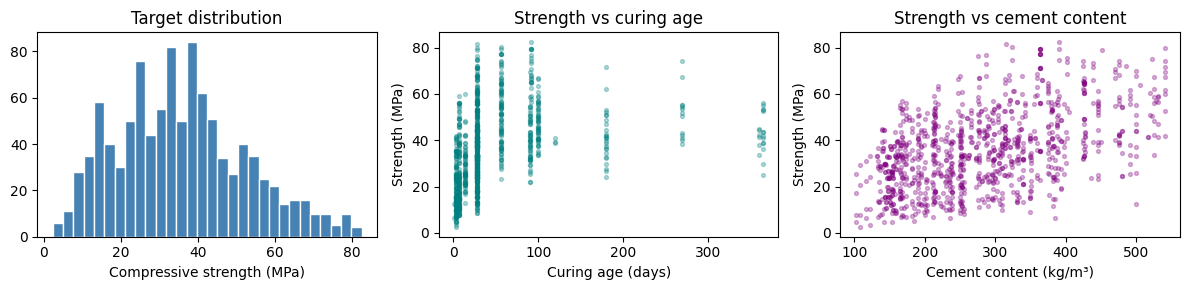

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

axes[0].hist(df['strength'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Compressive strength (MPa)')
axes[0].set_title('Target distribution')

axes[1].scatter(df['age'], df['strength'], s=8, alpha=0.3, color='teal')
axes[1].set_xlabel('Curing age (days)')
axes[1].set_ylabel('Strength (MPa)')
axes[1].set_title('Strength vs curing age')

axes[2].scatter(df['cement'], df['strength'], s=8, alpha=0.3, color='purple')
axes[2].set_xlabel('Cement content (kg/m³)')
axes[2].set_ylabel('Strength (MPa)')
axes[2].set_title('Strength vs cement content')

plt.tight_layout()
plt.show()

In [5]:
feature_names = [c for c in df.columns if c != 'strength']
X = df[feature_names].values
y = df['strength'].values

print(f'Features ({len(feature_names)}): {feature_names}')
print(f'Target range: {y.min():.1f} to {y.max():.1f} MPa')
print(f'Mean strength: {y.mean():.1f} MPa')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=315)
print(f'\nTraining samples: {X_train.shape[0]}')
print(f'Testing samples:  {X_test.shape[0]}')

results = {}

Features (8): ['cement', 'slag', 'fly_ash', 'water', 'superplasticizer', 'coarse_agg', 'fine_agg', 'age']
Target range: 2.3 to 82.6 MPa
Mean strength: 35.8 MPa

Training samples: 824
Testing samples:  206


## 1. Linear regression

Linear regression fits a weighted sum of the inputs plus an intercept: $\hat{y} = \mathbf{w}^\top \mathbf{x} + b$.

Use it as a baseline when you want a fast, interpretable first pass.

**Strengths:**
- Fast
- Easy to interpret
- Good baseline

**Weaknesses:**
- Limited for non-linear patterns
- Sensitive to outliers
- Weak on interactions without feature engineering

**Important hyperparameters:**
- `fit_intercept`: include an intercept term
- `copy_X`: keep a copy of the training matrix
- `n_jobs`: parallelization for some solver paths

**Preprocessing:** not required for fitting, though scaling can help if you want to compare coefficient sizes.

In [6]:
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

y_pred_lin = lin_model.predict(X_test)
lin_rmse   = root_mean_squared_error(y_test, y_pred_lin)
lin_r2     = r2_score(y_test, y_pred_lin)

print(f'Linear regression RMSE: {lin_rmse:.2f} MPa')
print(f'Linear regression R²:   {lin_r2:.3f}')
results['Linear regression'] = {'rmse': lin_rmse, 'r2': lin_r2}

Linear regression RMSE: 10.97 MPa
Linear regression R²:   0.596


### Side note: scaling

#### Scaling features

Does not effect prediction performance, but changes parameter estimates (**think** why?).

In [7]:
from sklearn.preprocessing import StandardScaler

feature_scaler = StandardScaler()
feature_scaler.fit(X_train)

X_train_scaled = feature_scaler.transform(X_train)
X_test_scaled = feature_scaler.transform(X_test)

feature_scaled_model = LinearRegression()
feature_scaled_model.fit(X_train_scaled, y_train)

y_pred_feature_scaled = feature_scaled_model.predict(X_test_scaled)
feature_scaled_rmse   = root_mean_squared_error(y_test, y_pred_feature_scaled)
feature_scaled_r2     = r2_score(y_test, y_pred_feature_scaled)

print(f'Linear regression (scaled features) RMSE: {feature_scaled_rmse:.2f} MPa')
print(f'Linear regression (scaled features)  R²:   {feature_scaled_r2:.3f}')

Linear regression (scaled features) RMSE: 10.97 MPa
Linear regression (scaled features)  R²:   0.596


#### Scaling labels

Scaling the label will effect RSS/RMSE/MAE metrics, but not R-squared (**think** why?).

In [8]:
label_scaler = StandardScaler()
label_scaler.fit(y_train.reshape(-1, 1))

y_train_scaled = label_scaler.transform(y_train.reshape(-1, 1))
y_test_scaled = label_scaler.transform(y_test.reshape(-1, 1))

label_scaled_model = LinearRegression()
label_scaled_model.fit(X_train, y_train_scaled)

y_pred_lin = label_scaled_model.predict(X_test)
lin_rmse   = root_mean_squared_error(y_test_scaled, y_pred_lin)
lin_r2     = r2_score(y_test_scaled, y_pred_lin)

print(f'Linear regression (scaled label) RMSE: {lin_rmse:.2f} MPa')
print(f'Linear regression (scaled label) R²:   {lin_r2:.3f}')

Linear regression (scaled label) RMSE: 0.66 MPa
Linear regression (scaled label) R²:   0.596


To get predictions in the original units, use the fitted scaler's `inverse_transform()` method on the raw output from the model to "undo" the scaling. Many Scikit-Learn transformers have this method for exactly this reason. 

In [9]:
unscaled_y_pred_lin = label_scaler.inverse_transform(y_pred_lin)
lin_rmse   = root_mean_squared_error(y_test, unscaled_y_pred_lin)
lin_r2     = r2_score(y_test, unscaled_y_pred_lin)

print(f'Linear regression (unscaled predictions) RMSE: {lin_rmse:.2f} MPa')
print(f'Linear regression (unscaled predictions) R²:   {lin_r2:.3f}')

Linear regression (unscaled predictions) RMSE: 10.97 MPa
Linear regression (unscaled predictions) R²:   0.596


#### Don't "mix-and-match"!

Can you spot the problem in the following code?

In [10]:
bad_predictions = feature_scaled_model.predict(X_test)

lin_rmse = root_mean_squared_error(y_test, bad_predictions)
lin_r2   = r2_score(y_test, bad_predictions)

print(f'Linear regression (bad) RMSE: {lin_rmse:.2f} MPa')
print(f'Linear regression (bad) R²:   {lin_r2:.3f}')

Linear regression (bad) RMSE: 7187.55 MPa
Linear regression (bad) R²:   -173479.223


The large RMSE value relative to the other experiments, and especially the huge negative R-squared should tell you that there is something fundamentally wrong here; way beyond just low model performance...

## 2. K-nearest neighbors (KNN) regression

KNN predicts from the average target value of the nearest training points.

**Strengths:**
- Simple
- Local and flexible
- Strong non-parametric baseline

**Weaknesses:**
- Slow at prediction time
- Sensitive to scale
- Struggles in high dimensions

**Important hyperparameters:**
- `n_neighbors`: number of neighbors to average
- `weights`: use uniform or distance weighting
- `metric`: distance function used for neighbor search

**Preprocessing:** scaling is essential.

In [11]:
from sklearn.neighbors import KNeighborsRegressor

knn_model = Pipeline([
    ('scaler', StandardScaler()),
    ('knn',    KNeighborsRegressor(n_neighbors=5, weights='distance'))
])
knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)
knn_rmse   = root_mean_squared_error(y_test, y_pred_knn)
knn_r2     = r2_score(y_test, y_pred_knn)

print(f'KNN RMSE: {knn_rmse:.2f} MPa')
print(f'KNN R²:   {knn_r2:.3f}')
results['KNN'] = {'rmse': knn_rmse, 'r2': knn_r2}

KNN RMSE: 7.84 MPa
KNN R²:   0.794


## 3. Decision tree regression

A decision tree splits the feature space into regions and predicts the mean target value in each leaf.

**Strengths:**
- No scaling needed
- Captures non-linear patterns
- Easy to visualize

**Weaknesses:**
- Can overfit
- Produces step-like predictions
- Poor extrapolation

**Important hyperparameters:**
- `max_depth`: limit tree depth
- `min_samples_leaf`: keep leaves from getting too small
- `min_samples_split`: require enough samples before splitting
- `max_features`: limit features considered at each split

**Preprocessing:** none required.

In [12]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(max_depth=5, random_state=315)
result = dt_model.fit(X_train, y_train)

y_pred_test_dt = dt_model.predict(X_test)
dt_test_rmse   = root_mean_squared_error(y_test, y_pred_test_dt)
dt_test_r2     = r2_score(y_test, y_pred_test_dt)

print(f'Decision tree RMSE: {dt_test_rmse:.2f} MPa')
print(f'Decision tree R²:   {dt_test_r2:.3f}')
results['Decision tree'] = {'rmse': dt_test_rmse, 'r2': dt_test_r2}

Decision tree RMSE: 8.61 MPa
Decision tree R²:   0.751


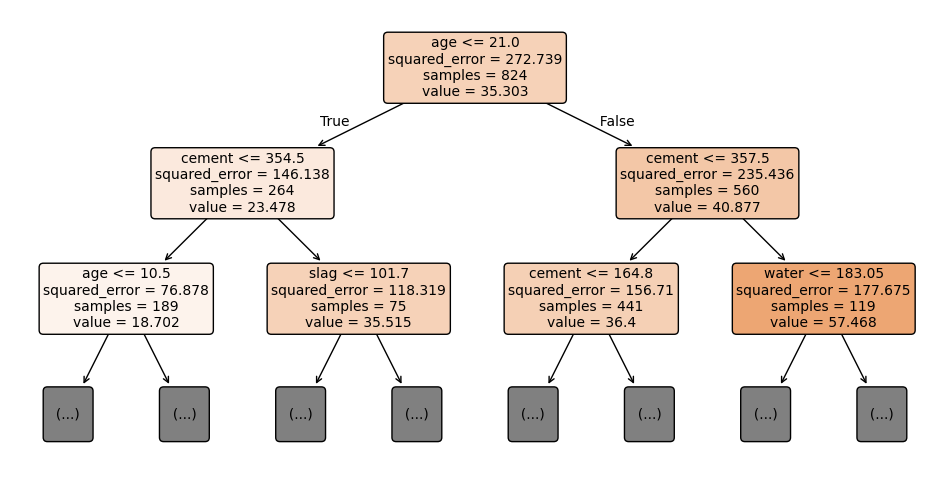

In [13]:
from sklearn.tree import plot_tree

plt.figure(figsize=(12, 6))
plot_tree(dt_model, max_depth=2, feature_names=feature_names, fontsize=10, filled=True, rounded=True)
plt.show()

## 4. Random forest regression

A random forest averages many decision trees to reduce variance and improve stability.

**Strengths:**
- Usually stronger than a single tree
- Handles non-linear patterns well
- Gives feature importance estimates

**Weaknesses:**
- Less interpretable
- Uses more memory
- Still cannot extrapolate well

**Important hyperparameters:**
- `n_estimators`: number of trees
- `max_depth`: maximum depth of each tree
- `min_samples_leaf`: minimum samples per leaf
- `max_features`: number of features checked at each split

**Preprocessing:** none required.

In [14]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=3,
    random_state=315,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
rf_rmse   = root_mean_squared_error(y_test, y_pred_rf)
rf_r2     = r2_score(y_test, y_pred_rf)

print(f'Random forest  RMSE: {rf_rmse:.2f} MPa')
print(f'Random forest  R²:   {rf_r2:.3f}')
results['Random forest'] = {'rmse': rf_rmse, 'r2': rf_r2}

Random forest  RMSE: 5.80 MPa
Random forest  R²:   0.887


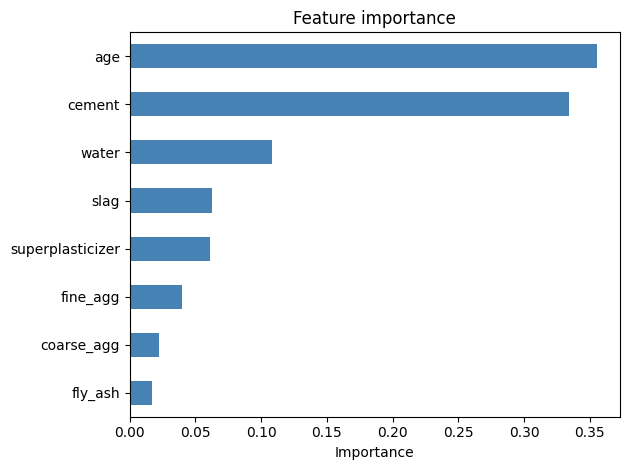

In [15]:
importances = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values()
importances.plot(kind='barh', color='steelblue', title='Feature importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 5. Optimized random forest regression

Here we tune a random forest with cross-validation and keep the best setting.

**Why this helps:** a small search can often beat a hand-picked default with little extra complexity.

**Important hyperparameters:**
- `n_estimators`: number of trees to search over
- `max_depth`: tree depth values to test
- `min_samples_leaf`: leaf size values to test
- `cv`: number of cross-validation folds

In [16]:
%%time

rf_param_grid = {
    'n_estimators': [50, 100, 200, 400],
    'max_depth': [4, 6, 8, 10, 12],
    'min_samples_leaf': [1, 2, 3, 4]
}

rf_search = GridSearchCV(
    RandomForestRegressor(random_state=315, n_jobs=-1),
    rf_param_grid,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

opt_rf_model = rf_search.best_estimator_
y_pred_opt_rf = opt_rf_model.predict(X_test)
opt_rf_rmse = root_mean_squared_error(y_test, y_pred_opt_rf)
opt_rf_r2 = r2_score(y_test, y_pred_opt_rf)

print(f'Best parameters: {rf_search.best_params_}')
print(f'Optimized random forest RMSE: {opt_rf_rmse:.2f} MPa')
print(f'Optimized random forest R²:   {opt_rf_r2:.3f}')
results['Optimized random forest'] = {'rmse': opt_rf_rmse, 'r2': opt_rf_r2}
print()

Best parameters: {'max_depth': 12, 'min_samples_leaf': 1, 'n_estimators': 400}
Optimized random forest RMSE: 5.23 MPa
Optimized random forest R²:   0.908

CPU times: user 4.2 s, sys: 167 ms, total: 4.37 s
Wall time: 24.9 s


## 6. Kernel idea (SVR and GPR intuition)

A kernel is a way to measure how similar two input rows are.

For bootcamp intuition, think of this as a smarter distance rule:
- If two rows are very similar, the model should give them similar predictions.
- If they are far apart, the model can predict very different values.

In SVR and GPR, the kernel is what lets the model capture curved patterns without us manually creating all those curve features.

A common choice is the RBF kernel:
$$
K(x_i, x_j) = \exp(-\gamma\,\|x_i-x_j\|^2)
$$

You do not need linear algebra here. Just remember:
- kernel value near 1 means very similar
- kernel value near 0 means not similar

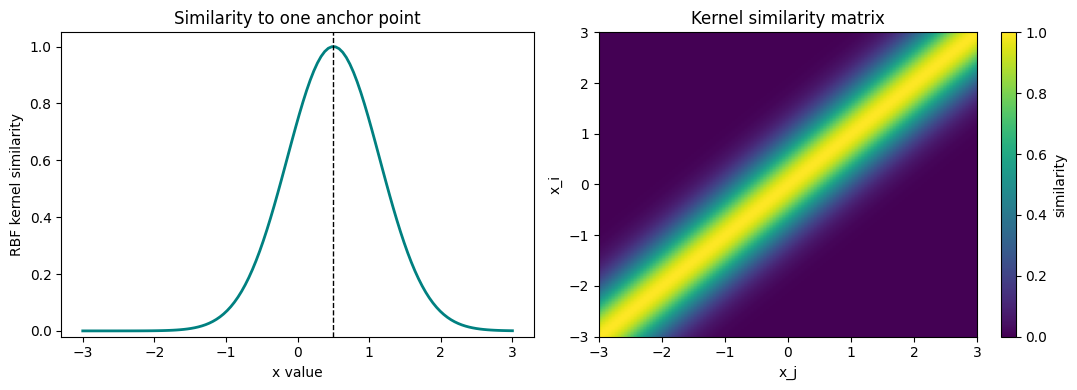

In [17]:
# Visual intuition for an RBF kernel in 1D
x = np.linspace(-3, 3, 120)
anchor = 0.5
gamma = 1.2

similarity_to_anchor = np.exp(-gamma * (x - anchor) ** 2)

# Pairwise similarity matrix: bright cells are highly similar pairs
X1, X2 = np.meshgrid(x, x)
K = np.exp(-gamma * (X1 - X2) ** 2)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(x, similarity_to_anchor, color='teal', linewidth=2)
axes[0].axvline(anchor, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Similarity to one anchor point')
axes[0].set_xlabel('x value')
axes[0].set_ylabel('RBF kernel similarity')
axes[0].set_ylim(-0.02, 1.05)

im = axes[1].imshow(K, origin='lower', extent=[x.min(), x.max(), x.min(), x.max()],
                    aspect='auto', cmap='viridis')
axes[1].set_title('Kernel similarity matrix')
axes[1].set_xlabel('x_j')
axes[1].set_ylabel('x_i')
fig.colorbar(im, ax=axes[1], label='similarity')

plt.tight_layout()
plt.show()

## 7. Support vector regression (SVR)

SVR predicts with a smooth curve while ignoring small errors inside an `epsilon` tube.

A beginner way to think about it:
- The kernel defines what counts as "nearby" points.
- Points that are nearby in kernel space should have similar predictions.
- Only the difficult points outside the tube strongly shape the final curve.

### Prediction equation

For a new input $x$, SVR prediction is:
$$
\hat{y}(x)=\sum_{i \in SV} w_i\,K(x_i, x)+b
$$

Where:
- $x_i$: support vectors from training
- $K(x_i, x)$: kernel similarity between support vector $x_i$ and new point $x$
- $w_i$: learned weights
- $b$: intercept

With the RBF kernel used here:
$$
K(x_i, x)=\exp\left(-\gamma\,\|x_i-x\|^2\right)
$$

### How to calculate one prediction

1. Scale the new input using the fitted scaler.
2. Compute kernel similarity from the new input to each support vector.
3. Multiply each similarity value by its learned weight.
4. Sum these weighted similarities.
5. Add the intercept $b$.
6. Return the result as the predicted value.

Why this is smooth: each RBF similarity term changes smoothly with distance, and a weighted sum of smooth terms is still smooth.

**Strengths:**
- Works well with a good kernel
- Handles non-linear patterns
- Robust to some outliers

**Weaknesses:**
- Needs scaling
- Sensitive to hyperparameters
- Can be slow on larger datasets

**Important hyperparameters:**
- `C`: controls regularization strength
- `epsilon`: width of the no-penalty tube
- `kernel`: shape of the regression function
- `gamma`: kernel width for RBF kernels

**Preprocessing:** scaling is mandatory.

In [ ]:
from sklearn.svm import SVR

svr_model = Pipeline([
    ('scaler', StandardScaler()),
    ('svr',    SVR(kernel='rbf', C=100, epsilon=1.0))
])
svr_model.fit(X_train, y_train)

y_pred_svr = svr_model.predict(X_test)
svr_rmse   = root_mean_squared_error(y_test, y_pred_svr)
svr_r2     = r2_score(y_test, y_pred_svr)

print(f'SVR RMSE: {svr_rmse:.2f} MPa')
print(f'SVR R²:   {svr_r2:.3f}')
results['SVR'] = {'rmse': svr_rmse, 'r2': svr_r2}

## 8. Gaussian process regression (GPR)

GPR predicts a full distribution at each point, not just one number.

In plain language:
- The kernel says how strongly each training point should influence another point.
- The model combines those influences to get a mean prediction.
- It also returns uncertainty, which usually grows in regions with less similar training data.

### Main equations

For a new point $x_*$, GPR returns:
$$
\mu_* = K(x_*, X)\,[K(X, X)+\sigma_n^2 I]^{-1} y
$$
$$
\sigma_*^2 = K(x_*, x_*) - K(x_*, X)\,[K(X, X)+\sigma_n^2 I]^{-1}K(X, x_*)
$$

Where:
- $\mu_*$ is the predicted mean
- $\sigma_*^2$ is the predicted variance (uncertainty)
- $K(\cdot,\cdot)$ comes from the chosen kernel
- $X, y$ are training inputs and targets
- $\sigma_n^2$ is noise level (captured by `WhiteKernel` or `alpha`)

### How to calculate one prediction

1. Scale the new input with the fitted scaler.
2. Compute kernel similarities between the new point and all training points.
3. Use the trained covariance term $[K(X, X)+\sigma_n^2 I]^{-1}$.
4. Multiply through to get the mean prediction $\mu_*$.
5. Compute $\sigma_*^2$ to get uncertainty at that point.
6. Report prediction as mean plus uncertainty (for example, $\mu_* \pm 1.96\sigma_*$).

**Strengths:**
- Gives uncertainty estimates
- Strong on small datasets
- Flexible Bayesian framework

**Weaknesses:**
- Expensive to train
- Kernel choice matters
- Does not scale well

**Important hyperparameters:**
- `kernel`: function prior, such as Matérn or RBF
- `n_restarts_optimizer`: extra kernel optimization attempts
- `alpha`: stability term added to the covariance matrix

**Preprocessing:** scaling is recommended.

In [ ]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel

scaler_gpr     = StandardScaler()
X_train_scaled = scaler_gpr.fit_transform(X_train)
X_test_scaled  = scaler_gpr.transform(X_test)

kernel = 1.0 * Matern(length_scale=np.ones(X_train.shape[1]), length_scale_bounds=(1e-2, 1e2), nu=1.5) + WhiteKernel(noise_level=1.0)

gpr_model = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=10,
    random_state=315,
    normalize_y=True
)

gpr_model.fit(X_train_scaled, y_train)

y_pred_gpr, y_std_gpr = gpr_model.predict(X_test_scaled, return_std=True)
gpr_rmse = root_mean_squared_error(y_test, y_pred_gpr)
gpr_r2   = r2_score(y_test, y_pred_gpr)

print(f'           GPR RMSE: {gpr_rmse:.2f} MPa')
print(f'             GPR R²: {gpr_r2:.3f}')
print(f'Mean prediction std: {y_std_gpr.mean():.2f} MPa')
results['GPR'] = {'rmse': gpr_rmse, 'r2': gpr_r2}

## 9. Model comparison

In [ ]:
names = list(results.keys())
rmses = [results[n]['rmse'] for n in names]
r2s   = [results[n]['r2']   for n in names]

order   = np.argsort(rmses)
names_s = [names[i] for i in order]
rmses_s = [rmses[i] for i in order]
r2s_s   = [r2s[i]   for i in order]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.barh(names_s, rmses_s, color='steelblue')
ax1.set_xlabel('Test RMSE (MPa) - lower is better')
ax1.set_title('Test RMSE by model')

ax2.barh(names_s, r2s_s, color='teal')
ax2.set_xlabel('Test R² - higher is better')
ax2.set_title('Test R² by model')
ax2.axvline(0, color='black', linewidth=0.8)

plt.suptitle('Concrete compressive strength', fontsize=16)
plt.tight_layout()
plt.show()

print(f'{"Model":<23} {"RMSE (MPa)":>12} {"R²":>8}')
print('-' * 45)

for n, r, r2 in zip(names_s, rmses_s, r2s_s):
    print(f'{n:<23} {r:>12.2f} {r2:>8.3f}')


## 10. Poisson regression

Poisson regression is a linear model for non-negative count data. It is a good match when the target is a count rather than a continuous value.

**Strengths:**
- Designed for counts
- Non-negative predictions
- Fast and interpretable

**Weaknesses:**
- Only for count targets
- Limited flexibility
- Assumes a Poisson-style mean/variance relationship

**Important hyperparameters:**
- `alpha`: L2 regularization strength
- `max_iter`: solver iteration limit

**Preprocessing:** scaling is recommended.

In [ ]:
url = 'https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/AER/DoctorVisits.csv'
df_v = pd.read_csv(url).drop(columns=['rownames'])

# Encode binary string columns as 0/1
df_v['gender']    = (df_v['gender']    == 'male').astype(int)
df_v['private']   = (df_v['private']   == 'yes').astype(int)
df_v['freepoor']  = (df_v['freepoor']  == 'yes').astype(int)
df_v['freerepat'] = (df_v['freerepat'] == 'yes').astype(int)
df_v['nchronic']  = (df_v['nchronic']  == 'yes').astype(int)
df_v['lchronic']  = (df_v['lchronic']  == 'yes').astype(int)

print(f'Shape: {df_v.shape}')
print()
print('Target distribution (visit counts):')
print(df_v['visits'].value_counts().sort_index().to_string())
df_v.head()

In [ ]:
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

axes[0].bar(
    df_v['visits'].value_counts().sort_index().index,
    df_v['visits'].value_counts().sort_index().values,
    color='steelblue', edgecolor='white'
)

axes[0].set_xlabel('Doctor visits (past 2 weeks)')
axes[0].set_ylabel('Count')
axes[0].set_title('Target distribution\n(most respondents had 0 visits)')


# Plot number of doctor visits vs number of illnesses using a normalized heatmap
heatmap_data = pd.crosstab(df_v['illness'], df_v['visits'], normalize='columns').sort_index(ascending=False)
sns.heatmap(heatmap_data, ax=axes[1], cmap='YlGnBu', cbar_kws={'label': 'Proportion'})

axes[1].set_xlabel('Number of illnesses (past 2 weeks)')
axes[1].set_ylabel('Doctor visits')
axes[1].set_title('Visits vs illnesses')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.linear_model import PoissonRegressor

feat_v = [c for c in df_v.columns if c != 'visits']
X_v    = df_v[feat_v].values
y_v    = df_v['visits'].values

X_train_v, X_test_v, y_train_v, y_test_v = train_test_split(
    X_v, y_v, test_size=0.2, random_state=315
)

poisson_model = Pipeline([
    ('scaler',  StandardScaler()),
    ('poisson', PoissonRegressor(alpha=1.0, max_iter=1000))
])
poisson_model.fit(X_train_v, y_train_v)

y_pred_v     = poisson_model.predict(X_test_v)
pois_rmse    = root_mean_squared_error(y_test_v, y_pred_v)
pois_r2      = r2_score(y_test_v, y_pred_v)
mean_pred    = y_pred_v.mean()
mean_actual  = y_test_v.mean()

print(f'Poisson RMSE:          {pois_rmse:.3f} visits')
print(f'Poisson R²:            {pois_r2:.3f}')
print(f'Mean predicted visits: {mean_pred:.3f}')
print(f'Mean actual visits:    {mean_actual:.3f}')
print()
print('Note: R² is low because 80% of respondents had 0 visits (zero-inflated data).')
print('RMSE relative to mean is a better measure: RMSE/mean =', round(pois_rmse / mean_actual, 2))
